In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from numpy.fft import fft2, ifft2, fftfreq

Total pasos: 200000, frames: 4000


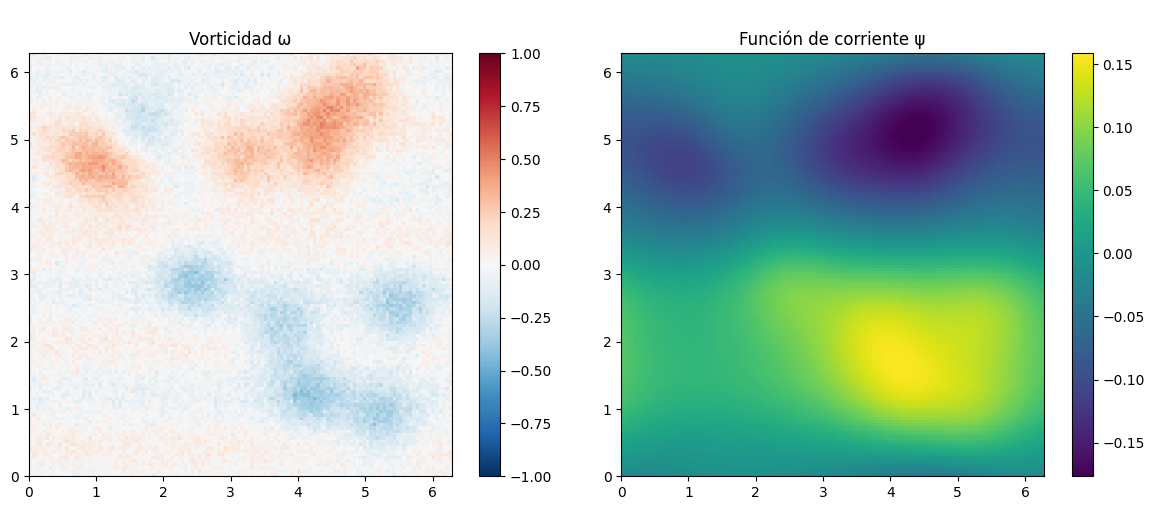

KeyboardInterrupt: 

In [6]:
L = 2.0 * np.pi
N = 128
dx = L / N
dy = dx

nu = 0.002
k_forcing = 4.0
dt = 0.0005
t_max = 100.0
n_steps = int(t_max / dt)

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

np.random.seed(42)
omega = 0.05 * np.random.randn(N, N)

n_vortices = 12
for i in range(n_vortices):
    cx = np.random.uniform(0.5, L-0.5)
    cy = np.random.uniform(0.5, L-0.5)
    signo = 1 if i % 2 == 0 else -1
    omega += signo * 0.3 * np.exp(-((X - cx)**2 + (Y - cy)**2) / 0.3)

kx = np.fft.fftfreq(N, d=dx) * 2 * np.pi
ky = np.fft.fftfreq(N, d=dy) * 2 * np.pi
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0, 0] = 1.0

def poisson_solver(omega):
    omega_hat = fft2(omega)
    psi_hat = -omega_hat / K2
    return np.real(ifft2(psi_hat))

def compute_velocity(psi):
    u = (np.roll(psi, -1, axis=0) - np.roll(psi, 1, axis=0)) / (2 * dy)
    v = -(np.roll(psi, -1, axis=1) - np.roll(psi, 1, axis=1)) / (2 * dx)
    return u, v

def advection(omega, u, v):
    domega_dx = (np.roll(omega, -1, axis=1) - np.roll(omega, 1, axis=1)) / (2 * dx)
    domega_dy = (np.roll(omega, -1, axis=0) - np.roll(omega, 1, axis=0)) / (2 * dy)
    return u * domega_dx + v * domega_dy

def diffusion(omega):
    return (np.roll(omega, -1, axis=1) + np.roll(omega, 1, axis=1) +
            np.roll(omega, -1, axis=0) + np.roll(omega, 1, axis=0) -
            4 * omega) / (dx * dx)

def forcing(y, k):
    return np.sin(k * y)

steps_per_frame = 50
frames = n_steps // steps_per_frame
print(f"Total pasos: {n_steps}, frames: {frames}")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax[0].imshow(omega, origin='lower', extent=[0, L, 0, L],
                   cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im1, ax=ax[0])
ax[0].set_title('Vorticidad ω')

psi = poisson_solver(omega)
im2 = ax[1].imshow(psi, origin='lower', extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(im2, ax=ax[1])
ax[1].set_title('Función de corriente ψ')

time_text = fig.suptitle('t = 0.00')

def update(frame):
    global omega, psi, u, v
    for _ in range(steps_per_frame):
        u, v = compute_velocity(psi)
        adv = advection(omega, u, v)
        diff = diffusion(omega)
        forc = forcing(Y, k_forcing)
        omega_new = omega + dt * (-adv + nu * diff + forc)
        psi_new = poisson_solver(omega_new)
        omega, psi = omega_new, psi_new
    
    im1.set_array(omega)
    im2.set_array(psi)
    tiempo = frame * steps_per_frame * dt
    time_text.set_text(f't = {tiempo:.2f}')
    return [im1, im2, time_text]

ani = FuncAnimation(fig, update, frames=frames, interval=50, blit=True)
plt.tight_layout()
plt.show()

ani.save('kolmogorov_500frames.gif', writer='pillow', fps=20)

Pre-calentamiento (3000 pasos) — forzamiento multi-escala...
  Paso          Ω    Ω tgt          U    U tgt       km   km tgt
─────────────────────────────────────────────────────────────────
   300     0.4848   0.1346     0.2383   0.0247   0.4284   0.5497
   600     1.4925   0.1346     0.4238   0.0247   0.4140   0.5497
   900     0.6202   0.1346     0.3956   0.0247   0.4819   0.5497
  1200     0.2787   0.1346     0.3710   0.0247   0.4183   0.5497
  1500     0.1991   0.1346     0.3706   0.0247   0.3409   0.5497
  1800     0.2823   0.1346     0.3906   0.0247   0.3840   0.5497
  2100     0.2004   0.1346     0.3871   0.0247   0.3582   0.5497
  2400     0.1421   0.1346     0.3807   0.0247   0.2956   0.5497
  2700     0.1369   0.1346     0.3796   0.0247   0.2827   0.5497
  3000     0.1328   0.1346     0.3772   0.0247   0.2734   0.5497
Warmup completo ✓

Grabando 100 snapshots...
  s= 20 | Ω=0.1352/0.1346 U=0.3775/0.0247 km=0.2746/0.5497
  s= 40 | Ω=0.1379/0.1346 U=0.3778/0.0247 km=0.2755/0.

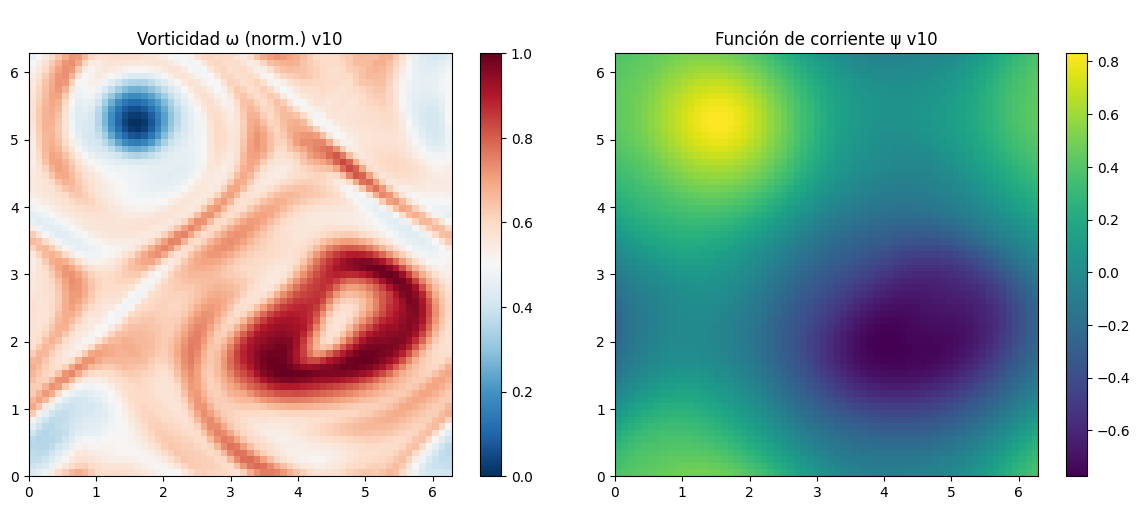

GIF guardado: simulacion_calibrada_v10.gif ✓


In [5]:
L  = 2.0 * np.pi
N  = 64
dx = L / N
nu = 0.001
dt = 0.05
n_warmup = 3000
n_steps  = 100

Z_target  = 0.134575
U_target  = 0.024729
km_target = 0.549738

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1.0

k_max   = N // 3
dealias = ((np.abs(KX) < k_max) & (np.abs(KY) < k_max)).astype(float)

kx_v       = fftfreq(N) * 2 * np.pi
ky_v       = fftfreq(N) * 2 * np.pi
KX_v, KY_v = np.meshgrid(kx_v, ky_v, indexing='ij')
K_v        = np.sqrt(KX_v**2 + KY_v**2)
k_vals_v   = np.unique(np.round(K_v, 6))
mask_k     = k_vals_v > 0

modos = [
    (4,  0.100),
    (8,  0.040),
    (12, 0.015),
    (14, 0.008),
    (15, 0.007),
    (16, 0.006),
    (17, 0.005),
    (18, 0.005),
    (19, 0.004),
    (20, 0.004),
    (21, 0.003),
    (22, 0.003),
    (23, 0.002),
]

def forcing_hat():
    f_hat = np.zeros((N, N), dtype=complex)
    for k_f, A_f in modos:
        if k_f < k_max:
            f_hat[k_f, 0]  += A_f * N**2 / 2
            f_hat[-k_f, 0] += A_f * N**2 / 2
    return f_hat


F_HAT = forcing_hat()

def get_psi_hat(omega_hat):
    psi_hat = -omega_hat / K2
    psi_hat[0,0] = 0.0
    return psi_hat

def get_velocity_hat(psi_hat):
    u_hat =  1j * KY * psi_hat
    v_hat = -1j * KX * psi_hat
    return u_hat, v_hat

def nonlinear(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)

    domega_dx_hat = 1j * KX * omega_hat
    domega_dy_hat = 1j * KY * omega_hat

    u  = np.real(ifft2(u_hat  * dealias))
    v  = np.real(ifft2(v_hat  * dealias))
    wx = np.real(ifft2(domega_dx_hat * dealias))
    wy = np.real(ifft2(domega_dy_hat * dealias))

    return fft2(u * wx + v * wy) * dealias

def rhs_hat(omega_hat):
    return (-nonlinear(omega_hat)
            - nu * K2 * omega_hat
            + F_HAT)

def rk4_step(omega_hat):
    k1 = rhs_hat(omega_hat)
    k2 = rhs_hat(omega_hat + 0.5*dt*k1)
    k3 = rhs_hat(omega_hat + 0.5*dt*k2)
    k4 = rhs_hat(omega_hat + dt*k3)
    return omega_hat + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def get_stats(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)

    omega = np.real(ifft2(omega_hat))
    u     = np.real(ifft2(u_hat))
    v     = np.real(ifft2(v_hat))

    Z  = 0.5 * np.mean(omega**2)
    U  = np.sqrt(np.mean(u**2 + v**2))

    oh = omega_hat / (N*N)
    pk = np.abs(oh)**2
    Ek = np.array([np.sum(pk[np.isclose(K_v, k, atol=1e-6)]) for k in k_vals_v])
    km = np.sum(k_vals_v[mask_k]*Ek[mask_k]) / (np.sum(Ek[mask_k]) + 1e-20)
    return Z, U, km, omega, np.real(ifft2(psi_hat))

np.random.seed(42)
omega_hat = np.zeros((N, N), dtype=complex)
for ki in range(-14, 15):
    for kj in range(-14, 15):
        if 0 < ki**2 + kj**2 <= 14**2:
            omega_hat[ki % N, kj % N] = (
                np.random.randn() + 1j*np.random.randn()
            ) * 0.01
omega_hat *= dealias

print(f"Pre-calentamiento ({n_warmup} pasos) — forzamiento multi-escala...")
print(f"{'Paso':>6} {'Ω':>10} {'Ω tgt':>8} {'U':>10} {'U tgt':>8} {'km':>8} {'km tgt':>8}")
print("─" * 65)

for s in range(n_warmup):
    omega_hat  = rk4_step(omega_hat)
    omega_hat *= dealias

    if (s+1) % 300 == 0:
        Z_t, U_t, km_t, _, _ = get_stats(omega_hat)
        print(f"{s+1:>6} {Z_t:>10.4f} {Z_target:>8.4f} "
              f"{U_t:>10.4f} {U_target:>8.4f} "
              f"{km_t:>8.4f} {km_target:>8.4f}")
        if np.isnan(Z_t):
            print("NaN detectado — abortando")
            break

print("Warmup completo ✓")

snapshots_vort   = np.zeros((n_steps, N, N))
snapshots_stream = np.zeros((n_steps, N, N))

print(f"\nGrabando {n_steps} snapshots...")
for s in range(n_steps):
    Z_t, U_t, km_t, omega, psi = get_stats(omega_hat)

    omega_norm        = (omega - omega.min()) / (omega.max() - omega.min() + 1e-10)
    snapshots_vort[s]   = omega_norm
    snapshots_stream[s] = psi

    omega_hat  = rk4_step(omega_hat)
    omega_hat *= dealias

    if (s+1) % 20 == 0:
        print(f"  s={s+1:3d} | Ω={Z_t:.4f}/{Z_target:.4f} "
              f"U={U_t:.4f}/{U_target:.4f} "
              f"km={km_t:.4f}/{km_target:.4f}")

print("Snapshots grabados ✓")

omega_all    = snapshots_vort - 0.5
psi_y, psi_x = np.gradient(snapshots_stream, 1.0, 1.0, axis=(-2,-1))
u_all        =  psi_y
v_all        = -psi_x

Z_sim   = 0.5 * np.mean(omega_all**2,          axis=(-2,-1))
U_sim   = np.sqrt(np.mean(u_all**2 + v_all**2, axis=(-2,-1)))
Ec_sim  = 0.5  * np.mean(u_all**2 + v_all**2,  axis=(-2,-1))
dw_y, dw_x = np.gradient(omega_all, 1.0, 1.0,  axis=(-2,-1))
Eta_sim = np.mean(dw_x**2 + dw_y**2,           axis=(-2,-1))

Km_sim = np.zeros(n_steps)
Le_sim = np.zeros(n_steps)
for s in range(n_steps):
    oh        = fft2(omega_all[s]) / (N*N)
    pk        = np.abs(oh)**2
    Ek        = np.array([np.sum(pk[np.isclose(K_v,k,atol=1e-6)]) for k in k_vals_v])
    Km_sim[s] = np.sum(k_vals_v[mask_k]*Ek[mask_k]) / np.sum(Ek[mask_k])
    Le_sim[s] = 2 * np.pi / Km_sim[s]

Tau_sim = Le_sim / U_sim

print("\n" + "═" * 65)
print(f"{'Cantidad':<25} {'Dataset':>12} {'Simulación':>12} {'Error %':>10}")
print("═" * 65)
comparacion = [
    ('Enstrofía Ω',         Z_target,  np.mean(Z_sim)),
    ('U_rms',               U_target,  np.mean(U_sim)),
    ('Energía cinética Ec', 0.000311,  np.mean(Ec_sim)),
    ('k_mean',              km_target, np.mean(Km_sim)),
    ('L_eff',               11.491548, np.mean(Le_sim)),
    ('Grad. vorticidad η',  0.002711,  np.mean(Eta_sim)),
    ('Tiempo remolino τ',   472.04,    np.mean(Tau_sim)),
]
for nombre, val_data, val_sim in comparacion:
    error = abs(val_sim - val_data) / abs(val_data) * 100
    ok    = "✅" if error < 20 else "⚠️"
    print(f"{nombre:<25} {val_data:>12.6f} {val_sim:>12.6f} {error:>9.1f}% {ok}")
print("═" * 65)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
im1 = axes[0].imshow(snapshots_vort[0], origin='lower',
                     extent=[0, L, 0, L], cmap='RdBu_r', vmin=0.0, vmax=1.0)
plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Vorticidad ω (norm.) v10')
im2 = axes[1].imshow(snapshots_stream[0], origin='lower',
                     extent=[0, L, 0, L], cmap='viridis')
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('Función de corriente ψ v10')
time_text = fig.suptitle('snapshot 0/100')

def update(frame):
    im1.set_array(snapshots_vort[frame])
    im2.set_array(snapshots_stream[frame])
    time_text.set_text(f'Snapshot {frame+1}/{n_steps} | '
                       f'ω mean={snapshots_vort[frame].mean():.3f} '
                       f'std={snapshots_vort[frame].std():.3f}')
    return [im1, im2, time_text]

ani = FuncAnimation(fig, update, frames=n_steps, interval=100, blit=True)
plt.tight_layout()
plt.show()
ani.save('simulacion_calibrada_v10.gif', writer='pillow', fps=10)
print("GIF guardado: simulacion_calibrada_v10.gif ✓")

Condición estabilidad IBM: dt/eta = 0.20 (debe ser < 1)
Celdas en obstáculo: 77 / 4096

Pre-calentamiento (3000 pasos)...
  Paso          Ω    Ω tgt          U    U tgt       km
──────────────────────────────────────────────────────────
   300     0.0240   0.1346     0.0516   0.0247   0.4643
   600     0.0885   0.1346     0.1003   0.0247   0.4526
   900     0.1853   0.1346     0.1466   0.0247   0.4445
  1200     0.3047   0.1346     0.1909   0.0247   0.4391
  1500     0.4310   0.1346     0.2330   0.0247   0.4371
  1800     0.5357   0.1346     0.2736   0.0247   0.4465
  2100     0.5691   0.1346     0.3017   0.0247   0.4653
  2400     0.5177   0.1346     0.3155   0.0247   0.5292
  2700     0.4744   0.1346     0.3386   0.0247   0.5081
  3000     0.4818   0.1346     0.3642   0.0247   0.4802
Warmup completo ✓

Grabando 2000 snapshots...
  s= 20 | Ω=0.4807/0.1346 U=0.3651/0.0247 km=0.4779/0.5497
  s= 40 | Ω=0.4795/0.1346 U=0.3661/0.0247 km=0.4753/0.5497
  s= 60 | Ω=0.4785/0.1346 U=0.3670/0.02

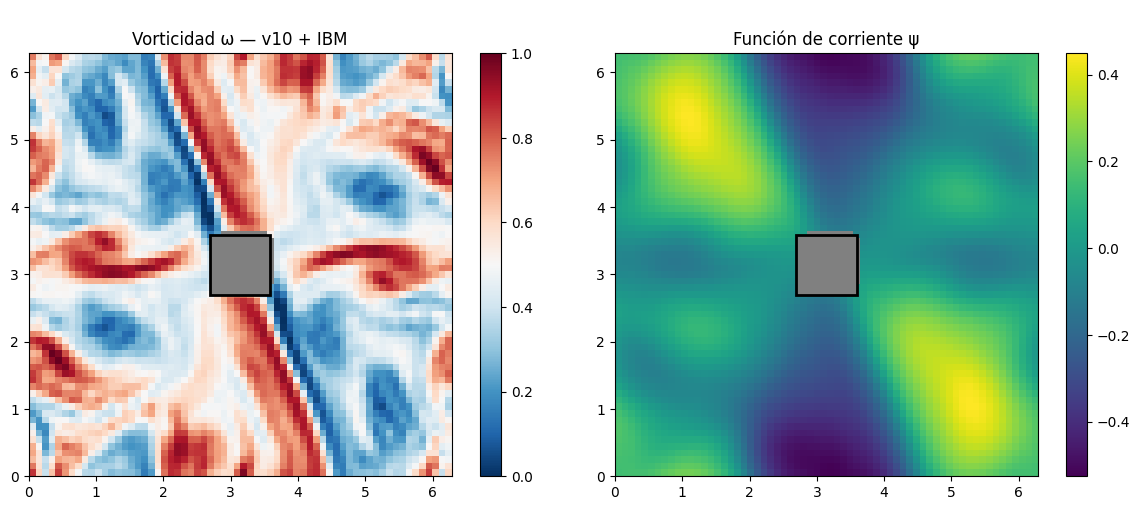

GIF guardado: v10_ibm_cuadrado.gif ✓


In [4]:
L  = 2.0 * np.pi
N  = 64
dx = L / N
dy = dx
nu = 0.001
dt = 0.01
n_warmup = 3000
n_steps  = 2000

Z_target  = 0.134575
U_target  = 0.024729
km_target = 0.549738

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

cx, cy = L/2, L/2
lado   = L / 7
eta    = 0.05      # dt/eta = 0.2 — estable
sigma  = 2.0 * dx  # transición suave

dist_x = lado/2 - np.abs(X - cx)
dist_y = lado/2 - np.abs(Y - cy)
chi    = (0.5 * (1 + np.tanh(dist_x / sigma)) *
          0.5 * (1 + np.tanh(dist_y / sigma)))

dchi_dx = np.gradient(chi, dx, axis=1)
dchi_dy = np.gradient(chi, dy, axis=0)

obstacle = chi > 0.5
fluid    = ~obstacle

print(f"Condición estabilidad IBM: dt/eta = {dt/eta:.2f} (debe ser < 1)")
print(f"Celdas en obstáculo: {obstacle.sum()} / {N*N}")

kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1.0
k_max   = N // 3
dealias = ((np.abs(KX) < k_max) & (np.abs(KY) < k_max)).astype(float)

kx_v       = fftfreq(N) * 2 * np.pi
ky_v       = fftfreq(N) * 2 * np.pi
KX_v, KY_v = np.meshgrid(kx_v, ky_v, indexing='ij')
K_v        = np.sqrt(KX_v**2 + KY_v**2)
k_vals_v   = np.unique(np.round(K_v, 6))
mask_k     = k_vals_v > 0

modos = [
    (4,  0.100),
    (8,  0.040),
    (12, 0.015),
    (14, 0.008),
    (15, 0.007),
    (16, 0.006),
    (17, 0.005),
    (18, 0.005),
    (19, 0.004),
    (20, 0.004),
    (21, 0.003),
    (22, 0.003),
    (23, 0.002),
]

def forcing_hat():
    f_hat = np.zeros((N, N), dtype=complex)
    for k_f, A_f in modos:
        if k_f < k_max:
            f_hat[k_f, 0]  += A_f * N**2 / 2
            f_hat[-k_f, 0] += A_f * N**2 / 2
    return f_hat

F_HAT = forcing_hat()

def get_psi_hat(omega_hat):
    psi_hat = -omega_hat / K2
    psi_hat[0,0] = 0.0
    return psi_hat

def get_velocity_hat(psi_hat):
    u_hat =  1j * KY * psi_hat
    v_hat = -1j * KX * psi_hat
    return u_hat, v_hat

def nonlinear(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)

    domega_dx_hat = 1j * KX * omega_hat
    domega_dy_hat = 1j * KY * omega_hat

    u  = np.real(ifft2(u_hat  * dealias))
    v  = np.real(ifft2(v_hat  * dealias))
    wx = np.real(ifft2(domega_dx_hat * dealias))
    wy = np.real(ifft2(domega_dy_hat * dealias))

    return fft2(u * wx + v * wy) * dealias

def ibm_term(omega_hat):
    """
    IBM penalización volumétrica:
    - Término vol:  χ/η · ω     → anula ω dentro del sólido
    - Término bnd:  ∇χ/η · u_t  → rebote en la frontera
    Condición estabilidad: dt/eta < 1
    """
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)

    omega_r = np.real(ifft2(omega_hat))
    u_r     = np.real(ifft2(u_hat * dealias))
    v_r     = np.real(ifft2(v_hat * dealias))

    vol_term = chi * omega_r / eta
    bnd_term = (dchi_dx * v_r - dchi_dy * u_r) / eta

    ibm = vol_term + bnd_term
    ibm = np.clip(ibm, -1e4, 1e4)

    return fft2(ibm) * dealias

def rhs_hat(omega_hat):
    return (-nonlinear(omega_hat)
            - nu * K2 * omega_hat
            + F_HAT
            - ibm_term(omega_hat))

def rk4_step(omega_hat):
    k1 = rhs_hat(omega_hat)
    k2 = rhs_hat(omega_hat + 0.5*dt*k1)
    k3 = rhs_hat(omega_hat + 0.5*dt*k2)
    k4 = rhs_hat(omega_hat + dt*k3)
    return (omega_hat + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)) * dealias

def get_stats(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)

    omega = np.real(ifft2(omega_hat))
    u     = np.real(ifft2(u_hat))
    v     = np.real(ifft2(v_hat))

    Z  = 0.5 * np.mean(omega[fluid]**2)
    U  = np.sqrt(np.mean(u[fluid]**2 + v[fluid]**2))

    oh = omega_hat / (N*N)
    pk = np.abs(oh)**2
    Ek = np.array([np.sum(pk[np.isclose(K_v, k, atol=1e-6)]) for k in k_vals_v])
    km = np.sum(k_vals_v[mask_k]*Ek[mask_k]) / (np.sum(Ek[mask_k]) + 1e-20)
    return Z, U, km, omega, np.real(ifft2(psi_hat))

np.random.seed(42)
omega_hat = np.zeros((N, N), dtype=complex)
for ki in range(-14, 15):
    for kj in range(-14, 15):
        if 0 < ki**2 + kj**2 <= 14**2:
            omega_hat[ki % N, kj % N] = (
                np.random.randn() + 1j*np.random.randn()
            ) * 0.01
omega_hat *= dealias

omega_init = np.real(ifft2(omega_hat))
omega_init[obstacle] = 0.0
omega_hat = fft2(omega_init) * dealias

print(f"\nPre-calentamiento ({n_warmup} pasos)...")
print(f"{'Paso':>6} {'Ω':>10} {'Ω tgt':>8} {'U':>10} {'U tgt':>8} {'km':>8}")
print("─" * 58)

for s in range(n_warmup):
    omega_hat = rk4_step(omega_hat)

    if (s+1) % 300 == 0:
        Z_t, U_t, km_t, _, _ = get_stats(omega_hat)
        print(f"{s+1:>6} {Z_t:>10.4f} {Z_target:>8.4f} "
              f"{U_t:>10.4f} {U_target:>8.4f} "
              f"{km_t:>8.4f}")
        if np.isnan(Z_t):
            print("NaN — abortando")
            break

print("Warmup completo ✓")

snapshots_vort   = np.zeros((n_steps, N, N))
snapshots_stream = np.zeros((n_steps, N, N))

print(f"\nGrabando {n_steps} snapshots...")
for s in range(n_steps):
    Z_t, U_t, km_t, omega, psi = get_stats(omega_hat)

    o_min = omega[fluid].min()
    o_max = omega[fluid].max()
    omega_norm = (omega - o_min) / (o_max - o_min + 1e-10)
    omega_norm[obstacle] = np.nan

    snapshots_vort[s]   = np.nan_to_num(omega_norm, nan=0.5)
    snapshots_stream[s] = psi

    omega_hat = rk4_step(omega_hat)

    if (s+1) % 20 == 0:
        print(f"  s={s+1:3d} | Ω={Z_t:.4f}/{Z_target:.4f} "
              f"U={U_t:.4f}/{U_target:.4f} "
              f"km={km_t:.4f}/{km_target:.4f}")

print("Snapshots grabados ✓")

omega_all    = snapshots_vort - 0.5
psi_y, psi_x = np.gradient(snapshots_stream, 1.0, 1.0, axis=(-2,-1))
u_all        =  psi_y
v_all        = -psi_x

Z_sim   = 0.5 * np.mean(omega_all**2,          axis=(-2,-1))
U_sim   = np.sqrt(np.mean(u_all**2 + v_all**2, axis=(-2,-1)))
Ec_sim  = 0.5  * np.mean(u_all**2 + v_all**2,  axis=(-2,-1))
dw_y, dw_x = np.gradient(omega_all, 1.0, 1.0,  axis=(-2,-1))
Eta_sim = np.mean(dw_x**2 + dw_y**2,           axis=(-2,-1))

Km_sim = np.zeros(n_steps)
Le_sim = np.zeros(n_steps)
for s in range(n_steps):
    oh        = fft2(omega_all[s]) / (N*N)
    pk        = np.abs(oh)**2
    Ek        = np.array([np.sum(pk[np.isclose(K_v,k,atol=1e-6)]) for k in k_vals_v])
    Km_sim[s] = np.sum(k_vals_v[mask_k]*Ek[mask_k]) / np.sum(Ek[mask_k])
    Le_sim[s] = 2 * np.pi / Km_sim[s]

Tau_sim = Le_sim / U_sim

print("\n" + "═" * 65)
print(f"{'Cantidad':<25} {'Dataset':>12} {'Simulación':>12} {'Error %':>10}")
print("═" * 65)
comparacion = [
    ('Enstrofía Ω',         Z_target,  np.mean(Z_sim)),
    ('U_rms',               U_target,  np.mean(U_sim)),
    ('Energía cinética Ec', 0.000311,  np.mean(Ec_sim)),
    ('k_mean',              km_target, np.mean(Km_sim)),
    ('L_eff',               11.491548, np.mean(Le_sim)),
    ('Grad. vorticidad η',  0.002711,  np.mean(Eta_sim)),
    ('Tiempo remolino τ',   472.04,    np.mean(Tau_sim)),
]
for nombre, val_data, val_sim in comparacion:
    error = abs(val_sim - val_data) / abs(val_data) * 100
    ok    = "✅" if error < 20 else "⚠️"
    print(f"{nombre:<25} {val_data:>12.6f} {val_sim:>12.6f} {error:>9.1f}% {ok}")
print("═" * 65)

cmap_vort = plt.cm.RdBu_r.copy()
cmap_vort.set_bad('gray', 1.0)
cmap_psi  = plt.cm.viridis.copy()
cmap_psi.set_bad('gray', 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def make_vis(snap):
    v = snap.copy().astype(float)
    v[obstacle] = np.nan
    return v

im1 = axes[0].imshow(make_vis(snapshots_vort[0]), origin='lower',
                     extent=[0,L,0,L], cmap=cmap_vort, vmin=0.0, vmax=1.0)
plt.colorbar(im1, ax=axes[0])
axes[0].set_title('Vorticidad ω — v10 + IBM')

im2 = axes[1].imshow(make_vis(snapshots_stream[0]), origin='lower',
                     extent=[0,L,0,L], cmap=cmap_psi)
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('Función de corriente ψ')

for ax in axes:
    rect = plt.Rectangle(
        (cx - lado/2, cy - lado/2), lado, lado,
        linewidth=2, edgecolor='black', facecolor='gray', zorder=5
    )
    ax.add_patch(rect)

time_text = fig.suptitle('snapshot 0/100')

def update(frame):
    im1.set_array(make_vis(snapshots_vort[frame]))
    im2.set_array(make_vis(snapshots_stream[frame]))
    time_text.set_text(f'Snapshot {frame+1}/{n_steps} | '
                       f'ω mean={snapshots_vort[frame][fluid].mean():.3f} '
                       f'std={snapshots_vort[frame][fluid].std():.3f}')
    return [im1, im2, time_text]

ani = FuncAnimation(fig, update, frames=n_steps, interval=50, blit=True)
plt.tight_layout()
plt.show()
ani.save('v10_ibm_cuadrado.gif', writer='pillow', fps=20)
print("GIF guardado: v10_ibm_cuadrado.gif ✓")

Warmup (3000 pasos)...
  500 | Ω=0.0630 U=0.0843
  1000 | Ω=0.2232 U=0.1616
  1500 | Ω=0.4310 U=0.2330
  2000 | Ω=0.5696 U=0.2955
  2500 | Ω=0.4974 U=0.3202
  3000 | Ω=0.4818 U=0.3642
Warmup completo ✓

═════════════════════════════════════════════
VERIFICACIÓN IBM
═════════════════════════════════════════════
u dentro obstáculo | mean=-0.000424 (debe ≈ 0)
v dentro obstáculo | mean=0.000171 (debe ≈ 0)
ω dentro obstáculo | mean=-0.029729 (debe ≈ 0)
u fuera obstáculo  | mean=0.000008
═════════════════════════════════════════════


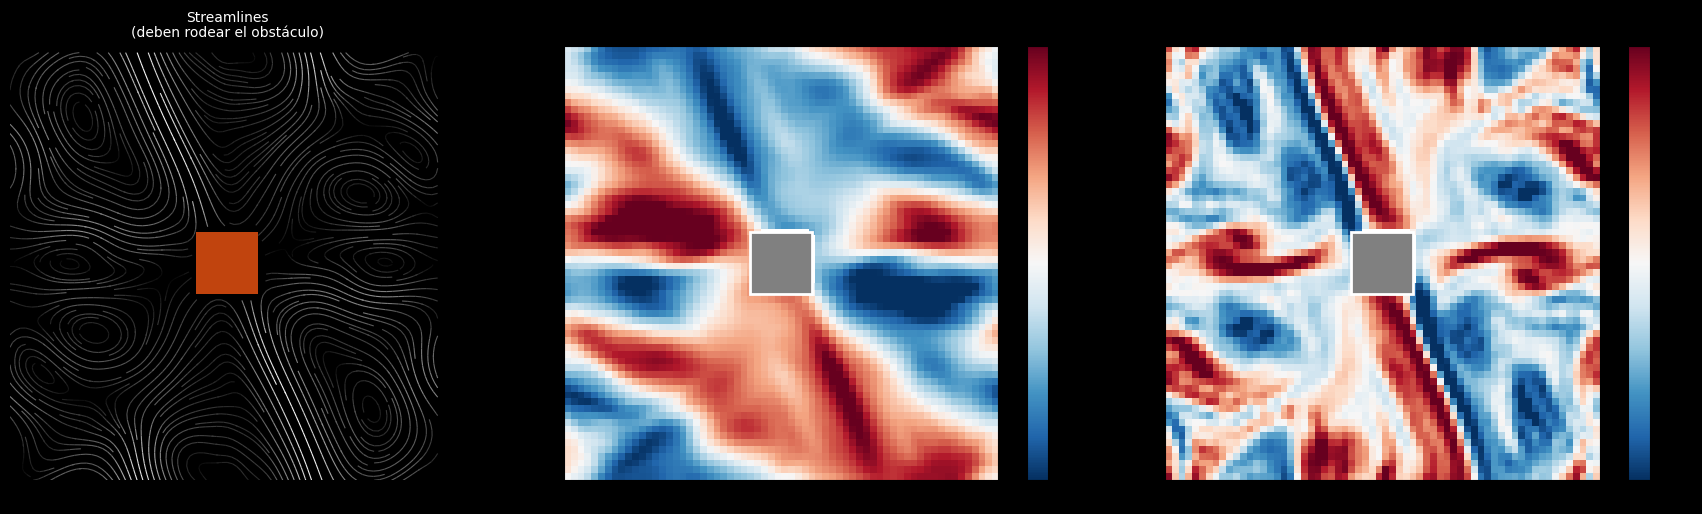

Guardado: verificacion_ibm.png ✓


In [1]:
L  = 2.0 * np.pi
N  = 64
dx = L / N
dy = dx
nu = 0.001
dt = 0.01
n_warmup = 3000

x = np.linspace(0, L, N, endpoint=False)
y = np.linspace(0, L, N, endpoint=False)
X, Y = np.meshgrid(x, y)

cx, cy = L/2, L/2
lado   = L / 7
eta    = 0.05
sigma  = 2.0 * dx

dist_x = lado/2 - np.abs(X - cx)
dist_y = lado/2 - np.abs(Y - cy)
chi    = (0.5*(1 + np.tanh(dist_x/sigma)) *
          0.5*(1 + np.tanh(dist_y/sigma)))

dchi_dx = np.gradient(chi, dx, axis=1)
dchi_dy = np.gradient(chi, dy, axis=0)

obstacle = chi > 0.5
fluid    = ~obstacle

kx = fftfreq(N, d=1.0/N)
ky = fftfreq(N, d=1.0/N)
KX, KY = np.meshgrid(kx, ky)
K2 = KX**2 + KY**2
K2[0,0] = 1.0
k_max   = N // 3
dealias = ((np.abs(KX) < k_max) & (np.abs(KY) < k_max)).astype(float)

modos = [
    (4,0.100),(8,0.040),(12,0.015),(14,0.008),(15,0.007),
    (16,0.006),(17,0.005),(18,0.005),(19,0.004),(20,0.004),
    (21,0.003),(22,0.003),(23,0.002),
]
F_HAT = np.zeros((N,N), dtype=complex)
for k_f, A_f in modos:
    if k_f < k_max:
        F_HAT[k_f, 0]  += A_f * N**2 / 2
        F_HAT[-k_f, 0] += A_f * N**2 / 2

def get_psi_hat(omega_hat):
    psi_hat = -omega_hat / K2
    psi_hat[0,0] = 0.0
    return psi_hat

def get_velocity_hat(psi_hat):
    return 1j*KY*psi_hat, -1j*KX*psi_hat

def nonlinear(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)
    u  = np.real(ifft2(u_hat  * dealias))
    v  = np.real(ifft2(v_hat  * dealias))
    wx = np.real(ifft2(1j*KX*omega_hat * dealias))
    wy = np.real(ifft2(1j*KY*omega_hat * dealias))
    return fft2(u*wx + v*wy) * dealias

def ibm_term(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)
    omega_r = np.real(ifft2(omega_hat))
    u_r     = np.real(ifft2(u_hat * dealias))
    v_r     = np.real(ifft2(v_hat * dealias))
    vol     = chi * omega_r / eta
    bnd     = (dchi_dx * v_r - dchi_dy * u_r) / eta
    return fft2(np.clip(vol + bnd, -1e4, 1e4)) * dealias

def rhs_hat(omega_hat):
    return (-nonlinear(omega_hat)
            - nu * K2 * omega_hat
            + F_HAT
            - ibm_term(omega_hat))

def rk4_step(omega_hat):
    k1 = rhs_hat(omega_hat)
    k2 = rhs_hat(omega_hat + 0.5*dt*k1)
    k3 = rhs_hat(omega_hat + 0.5*dt*k2)
    k4 = rhs_hat(omega_hat + dt*k3)
    return (omega_hat + (dt/6.0)*(k1+2*k2+2*k3+k4)) * dealias

def get_fields(omega_hat):
    psi_hat      = get_psi_hat(omega_hat)
    u_hat, v_hat = get_velocity_hat(psi_hat)
    return (np.real(ifft2(omega_hat)),
            np.real(ifft2(psi_hat)),
            np.real(ifft2(u_hat)),
            np.real(ifft2(v_hat)))

np.random.seed(42)
omega_hat = np.zeros((N,N), dtype=complex)
for ki in range(-14, 15):
    for kj in range(-14, 15):
        if 0 < ki**2 + kj**2 <= 14**2:
            omega_hat[ki%N, kj%N] = (
                np.random.randn() + 1j*np.random.randn()
            ) * 0.01
omega_hat *= dealias
omega_init = np.real(ifft2(omega_hat))
omega_init[obstacle] = 0.0
omega_hat = fft2(omega_init) * dealias

print(f"Warmup ({n_warmup} pasos)...")
for s in range(n_warmup):
    omega_hat = rk4_step(omega_hat)
    if (s+1) % 500 == 0:
        omega, _, u, v = get_fields(omega_hat)
        print(f"  {s+1} | Ω={0.5*np.mean(omega[fluid]**2):.4f} "
              f"U={np.sqrt(np.mean(u[fluid]**2+v[fluid]**2)):.4f}")
print("Warmup completo ✓")

omega, psi, u, v = get_fields(omega_hat)

print("\n" + "═"*45)
print("VERIFICACIÓN IBM")
print("═"*45)
print(f"u dentro obstáculo | mean={u[obstacle].mean():.6f} (debe ≈ 0)")
print(f"v dentro obstáculo | mean={v[obstacle].mean():.6f} (debe ≈ 0)")
print(f"ω dentro obstáculo | mean={omega[obstacle].mean():.6f} (debe ≈ 0)")
print(f"u fuera obstáculo  | mean={u[fluid].mean():.6f}")
print("═"*45)

u_plot = u.copy(); u_plot[obstacle] = np.nan
v_plot = v.copy(); v_plot[obstacle] = np.nan
speed  = np.sqrt(u**2 + v**2); speed[obstacle] = np.nan

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('black')

axes[0].set_facecolor('black')
axes[0].streamplot(
    x, y, u_plot, v_plot,
    density   = 2.5,
    color     = speed,
    cmap      = 'gray',
    linewidth = 0.8,
    arrowsize = 0.01,
    norm      = Normalize(vmin=0, vmax=np.nanmax(speed))
)
axes[0].add_patch(plt.Rectangle(
    (cx-lado/2, cy-lado/2), lado, lado,
    linewidth=0, facecolor='#C1440E', zorder=10
))
axes[0].set_xlim(0,L); axes[0].set_ylim(0,L)
axes[0].set_aspect('equal'); axes[0].axis('off')
axes[0].set_title('Streamlines\n(deben rodear el obstáculo)',
                  color='white', fontsize=10)

u_vis = u.copy(); u_vis[obstacle] = np.nan
vmax_u = np.nanpercentile(np.abs(u[fluid]), 95)
im2 = axes[1].imshow(u_vis, origin='lower', extent=[0,L,0,L],
                     cmap='RdBu_r', aspect='equal',
                     vmin=-vmax_u, vmax=vmax_u)
axes[1].add_patch(plt.Rectangle(
    (cx-lado/2, cy-lado/2), lado, lado,
    linewidth=2, edgecolor='white', facecolor='gray', zorder=5
))
plt.colorbar(im2, ax=axes[1])
axes[1].set_title('Velocidad u\n(gris=obstáculo, debe ser ≈0 dentro)',
                  fontsize=10)

w_vis  = omega.copy(); w_vis[obstacle] = np.nan
vmax_w = np.nanpercentile(np.abs(omega[fluid]), 95)
im3 = axes[2].imshow(w_vis, origin='lower', extent=[0,L,0,L],
                     cmap='RdBu_r', aspect='equal',
                     vmin=-vmax_w, vmax=vmax_w)
axes[2].add_patch(plt.Rectangle(
    (cx-lado/2, cy-lado/2), lado, lado,
    linewidth=2, edgecolor='white', facecolor='gray', zorder=5
))
plt.colorbar(im3, ax=axes[2])
axes[2].set_title('Vorticidad ω\n(debe ser ≈0 dentro del obstáculo)',
                  fontsize=10)

plt.tight_layout()
plt.savefig('verificacion_ibm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Guardado: verificacion_ibm.png ✓")